In [ ]:
!pip install -q kaggle pillow numpy tqdm scikit-learn matplotlib seaborn torch torchvision
print('Dependencies installed.')

Dependencies installed.


In [ ]:
from google.colab import files
import os

print('Upload kaggle (1).json (only needed once per Colab session)...')
uploaded = files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
print('Kaggle credentials configured.')

Upload kaggle (1).json (only needed once per Colab session)...


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


In [ ]:
import pathlib

RAW_DIR = pathlib.Path('/content/raw')
RAW_DIR.mkdir(parents=True, exist_ok=True)

if not any(RAW_DIR.iterdir()):
    !kaggle datasets download -d sriramr/fruits-fresh-and-rotten-for-classification -p /content/raw --unzip -q
    print('Dataset downloaded.')
else:
    print('Dataset already present, skipping download.')

!ls /content/raw

Dataset URL: https://www.kaggle.com/datasets/sriramr/fruits-fresh-and-rotten-for-classification
License(s): unknown
Dataset downloaded.
dataset


In [ ]:
import re, glob, random
from collections import defaultdict

random.seed(42)

LABEL_PATTERNS = [
    (re.compile(r'rotten', re.I), 'Rotten'),
    (re.compile(r'stale',  re.I), 'Rotten'),
    (re.compile(r'fresh',  re.I), 'Fresh'),
]

FRUIT_PATTERNS = {
    'apple':  re.compile(r'apple',  re.I),
    'banana': re.compile(r'banana', re.I),
    'orange': re.compile(r'orange', re.I),
}

def label_for(path):
    for pat, lbl in LABEL_PATTERNS:
        if pat.search(path):
            return lbl
    return None

def fruit_for(path):
    for ft, pat in FRUIT_PATTERNS.items():
        if pat.search(path):
            return ft
    return 'default'

records = []
for img_path in glob.glob('/content/raw/**/*', recursive=True):
    if not img_path.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    lbl = label_for(img_path)
    if lbl is None:
        continue
    records.append((img_path, lbl, fruit_for(img_path)))

print(f'Indexed {len(records)} raw images')
raw_counts = defaultdict(int)
for _, lbl, _ in records:
    raw_counts[lbl] += 1
for k, v in raw_counts.items():
    print(f'  {k}: {v}')

Indexed 27198 raw images
  Rotten: 15390
  Fresh: 11808


In [ ]:
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

def is_ripe(path, fruit):
    try:
        img = Image.open(path).convert('RGB').resize((96, 96), Image.BILINEAR)
    except Exception:
        return False
    arr = np.asarray(img, dtype=np.float32) / 255.0
    r, g, b = arr[..., 0], arr[..., 1], arr[..., 2]
    mx, mn = arr.max(-1), arr.min(-1)
    s = np.where(mx > 1e-6, (mx - mn) / (mx + 1e-6), 0)
    fg = ~((mx > 0.93) & (s < 0.12))
    if fg.sum() < 50:
        return False
    delta = mx - mn + 1e-8
    h = np.zeros_like(mx)
    m = (mx == r); h[m] = ((g[m] - b[m]) / delta[m]) % 6
    m = (mx == g); h[m] = (b[m] - r[m]) / delta[m] + 2
    m = (mx == b); h[m] = (r[m] - g[m]) / delta[m] + 4
    h = h * 60.0
    yellow_orange = fg & (h >= 18) & (h <= 65) & (s > 0.45) & (mx > 0.55)
    deep_red      = fg & ((h < 15) | (h > 340)) & (s > 0.55) & (mx > 0.35)
    green         = fg & (h >= 70) & (h <= 170) & (s > 0.35) & (mx > 0.35)
    ripe_score = (yellow_orange | deep_red).sum() / max(fg.sum(), 1)
    fresh_score = green.sum() / max(fg.sum(), 1)
    if fruit == 'banana':
        return ripe_score > 0.20 and ripe_score > fresh_score
    if fruit == 'apple':
        return ripe_score > 0.18 and ripe_score > fresh_score
    if fruit == 'orange':
        return ripe_score > 0.25
    return ripe_score > 0.25 and ripe_score > fresh_score

new_records = []
for path, lbl, fruit in tqdm(records, desc='Splitting Fresh into Fresh/Ripe'):
    if lbl == 'Fresh' and is_ripe(path, fruit):
        new_records.append((path, 'Ripe', fruit))
    else:
        new_records.append((path, lbl, fruit))
records = new_records

counts = defaultdict(int)
for _, lbl, _ in records:
    counts[lbl] += 1
print('After Ripe extraction:')
for k, v in counts.items():
    print(f'  {k}: {v}')

Splitting Fresh into Fresh/Ripe:   0%|          | 0/27198 [00:00<?, ?it/s]

After Ripe extraction:
  Rotten: 15390
  Ripe: 10366
  Fresh: 1442



```
/content/data/fruitsense/
├── train/
│   ├── Fresh/
│   ├── Ripe/
│   └── Rotten/
└── test/
    ├── Fresh/
    ├── Ripe/
    └── Rotten/
```

In [ ]:
import shutil
from sklearn.model_selection import train_test_split

OUT_ROOT = pathlib.Path('/content/data/fruitsense')
if OUT_ROOT.exists():
    shutil.rmtree(OUT_ROOT)
for split in ['train', 'test']:
    for cls in ['Fresh', 'Ripe', 'Rotten']:
        (OUT_ROOT / split / cls).mkdir(parents=True, exist_ok=True)

by_class = defaultdict(list)
for r in records:
    by_class[r[1]].append(r)
target = min(len(v) for v in by_class.values())
target = min(target, 1500)   # cap for fast demo run
print(f'Capping each class to {target} samples (demo size)')

balanced = []
for cls, items in by_class.items():
    random.shuffle(items)
    balanced.extend(items[:target])

train, test = train_test_split(
    balanced, test_size=0.15,
    stratify=[r[1] for r in balanced], random_state=42,
)

for items, split in [(train, 'train'), (test, 'test')]:
    for i, (path, cls, fruit) in enumerate(tqdm(items, desc=f'Writing {split}')):
        dst = OUT_ROOT / split / cls / f'{fruit}_{i:06d}{pathlib.Path(path).suffix.lower()}'
        try:
            shutil.copyfile(path, dst)
        except Exception:
            pass

print('\nFinal dataset structure:')
!find /content/data/fruitsense -maxdepth 2 -type d

Capping each class to 1442 samples (demo size)


Writing train:   0%|          | 0/3677 [00:00<?, ?it/s]

Writing test:   0%|          | 0/649 [00:00<?, ?it/s]


Final dataset structure:
/content/data/fruitsense
/content/data/fruitsense/train
/content/data/fruitsense/train/Fresh
/content/data/fruitsense/train/Rotten
/content/data/fruitsense/train/Ripe
/content/data/fruitsense/test
/content/data/fruitsense/test/Fresh
/content/data/fruitsense/test/Rotten
/content/data/fruitsense/test/Ripe


In [ ]:
import pandas as pd

summary = []
for split in ['train', 'test']:
    for cls in ['Fresh', 'Ripe', 'Rotten']:
        n = len(list((OUT_ROOT / split / cls).iterdir()))
        summary.append({'split': split, 'class': cls, 'count': n})

df = pd.DataFrame(summary)
pivot = df.pivot(index='class', columns='split', values='count')
pivot['total'] = pivot.sum(axis=1)
pivot.loc['TOTAL'] = pivot.sum()
print('Dataset distribution:\n')
print(pivot.to_string())

Dataset distribution:

split   test  train  total
class                     
Fresh    216   1226   1442
Ripe     216   1226   1442
Rotten   217   1225   1442
TOTAL    649   3677   4326


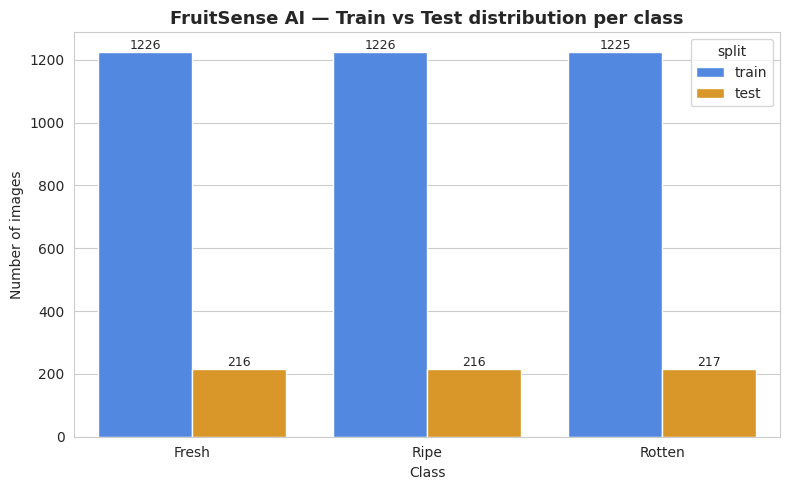

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = df.copy()
sns.barplot(data=plot_df, x='class', y='count', hue='split',
            palette={'train': '#3b82f6', 'test': '#f59e0b'}, ax=ax)
ax.set_title('FruitSense AI — Train vs Test distribution per class', fontsize=13, weight='bold')
ax.set_xlabel('Class')
ax.set_ylabel('Number of images')
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

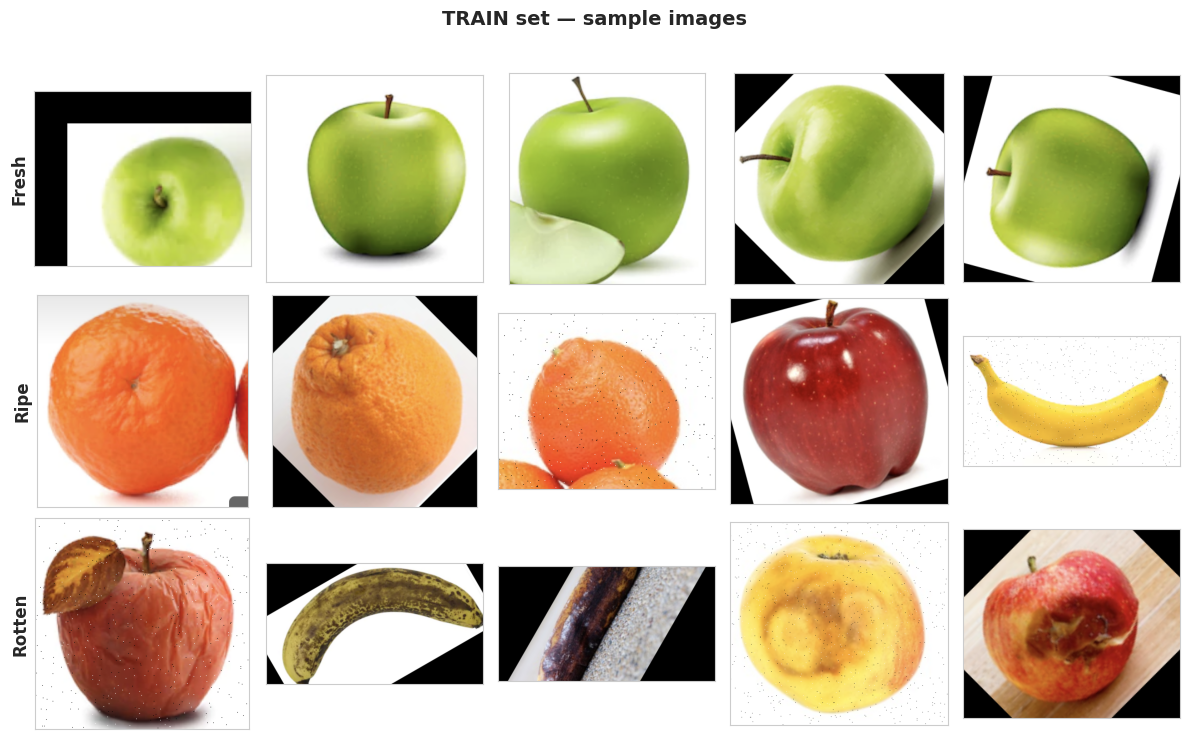

In [ ]:
def show_grid(split_name, n_per_class=5):
    classes = ['Fresh', 'Ripe', 'Rotten']
    fig, axes = plt.subplots(len(classes), n_per_class,
                              figsize=(n_per_class * 2.4, len(classes) * 2.4))
    fig.suptitle(f'{split_name.upper()} set — sample images',
                  fontsize=14, weight='bold', y=1.02)
    for r, cls in enumerate(classes):
        files_ = sorted((OUT_ROOT / split_name / cls).iterdir())
        random.shuffle(files_)
        for c in range(n_per_class):
            ax = axes[r, c]
            if c < len(files_):
                ax.imshow(Image.open(files_[c]).convert('RGB'))
            ax.set_xticks([]); ax.set_yticks([])
            if c == 0:
                ax.set_ylabel(cls, fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()

show_grid('train', n_per_class=5)

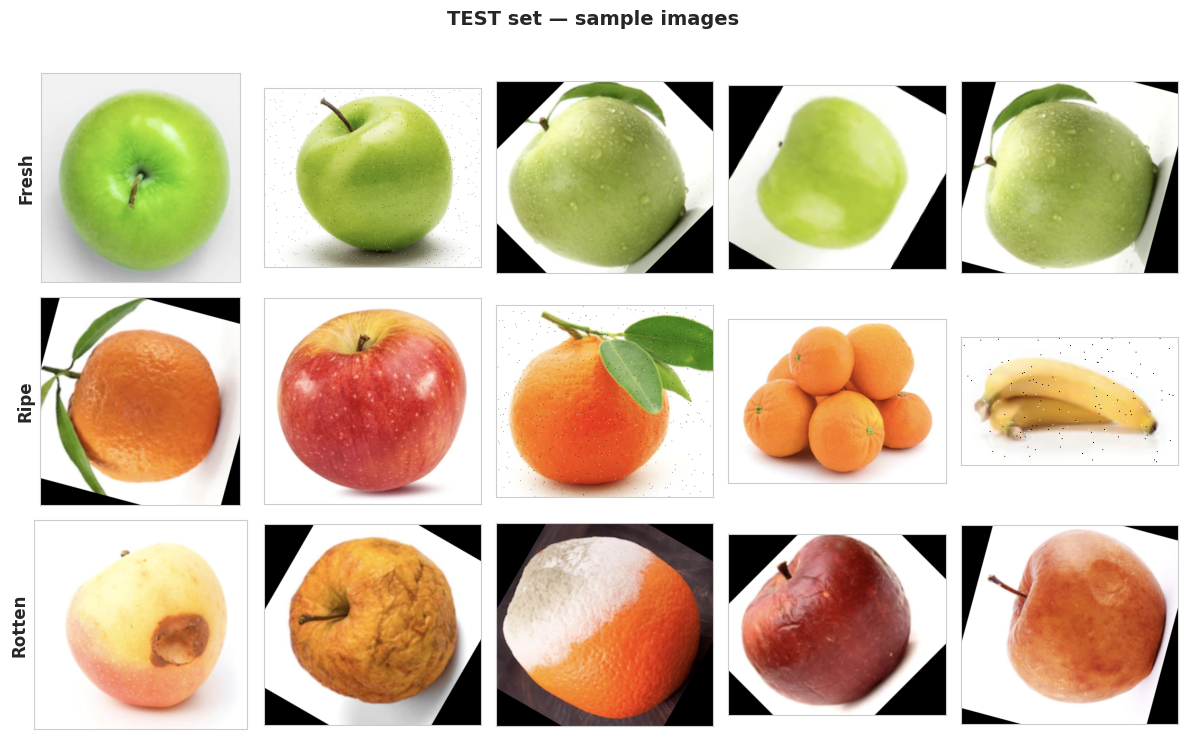

In [ ]:
show_grid('test', n_per_class=5)

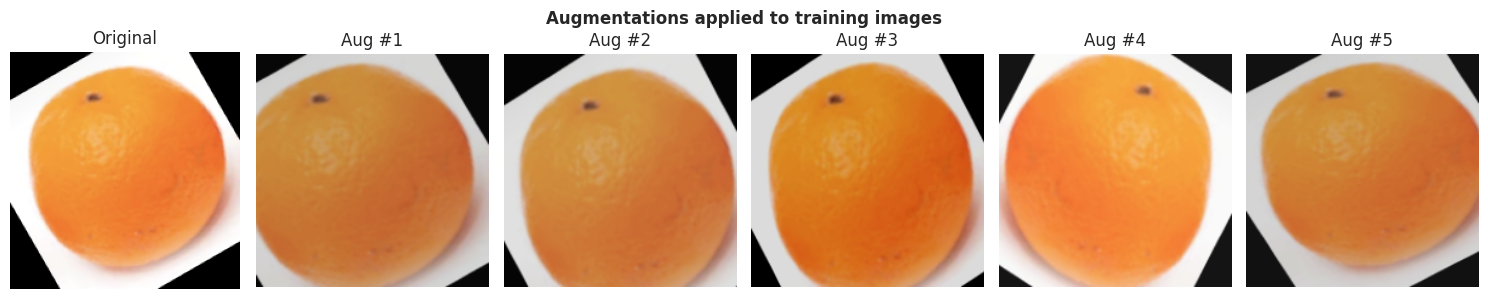

In [ ]:
from torchvision import transforms

IMG = 224
NORMALIZE = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.15, 0.15, 0.15),
    transforms.ToTensor(),
    NORMALIZE,
])
test_tf = transforms.Compose([
    transforms.Resize(int(IMG * 1.15)),
    transforms.CenterCrop(IMG),
    transforms.ToTensor(),
    NORMALIZE,
])

vis_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.15, 0.15, 0.15),
])

sample_path = next((OUT_ROOT / 'train' / 'Ripe').iterdir())
img = Image.open(sample_path).convert('RGB')
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(img); axes[0].set_title('Original'); axes[0].axis('off')
for i in range(5):
    axes[i + 1].imshow(vis_tf(img)); axes[i + 1].set_title(f'Aug #{i+1}'); axes[i + 1].axis('off')
plt.suptitle('Augmentations applied to training images', weight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

train_ds = datasets.ImageFolder(str(OUT_ROOT / 'train'), transform=train_tf)
test_ds  = datasets.ImageFolder(str(OUT_ROOT / 'test'),  transform=test_tf)

print('Class index :', train_ds.class_to_idx)
print(f'Train size  : {len(train_ds)}')
print(f'Test size   : {len(test_ds)}')

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f'\nBatches per epoch — train: {len(train_loader)}  | test: {len(test_loader)}')

Device: cuda
Class index : {'Fresh': 0, 'Ripe': 1, 'Rotten': 2}
Train size  : 3677
Test size   : 649

Batches per epoch — train: 58  | test: 11


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DCFLayer(nn.Module):
    def __init__(self, in_channels, spatial=14, sigma=2.0, lam=0.01):
        super().__init__()
        self.spatial, self.lam = spatial, lam
        coords = torch.arange(spatial).float() - (spatial - 1) / 2.0
        yy, xx = torch.meshgrid(coords, coords, indexing='ij')
        g = torch.exp(-(xx ** 2 + yy ** 2) / (2.0 * sigma ** 2))
        g = g / (g.sum() + 1e-8)
        self.register_buffer('gaussian', g.unsqueeze(0).unsqueeze(0))
        self.out_dim = in_channels
    def forward(self, x):
        b, c, h, w = x.shape
        if (h, w) != (self.spatial, self.spatial):
            x = F.adaptive_avg_pool2d(x, (self.spatial, self.spatial))
            h = w = self.spatial
        g = self.gaussian.to(x.device).expand(b, c, h, w)
        f_hat = torch.fft.rfft2(x); g_hat = torch.fft.rfft2(g)
        denom = (f_hat.conj() * f_hat).real + self.lam
        h_filter = (f_hat.conj() * g_hat) / denom
        response = torch.fft.irfft2(f_hat * h_filter, s=(h, w))
        return response.mean(dim=[2, 3])

class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Conv2d(in_c, out_c, 3, padding=1)
        self.bn = nn.BatchNorm2d(out_c)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        return self.pool(F.relu(self.bn(self.conv(x))))

class FruitSenseNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.block1 = ConvBlock(3, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.block4 = ConvBlock(128, 256)
        self.block5 = ConvBlock(256, 512)
        self.dcfnet = DCFLayer(in_channels=128, spatial=14)
        self.gap = nn.AdaptiveAvgPool2d(1)
        feat = 512 + self.dcfnet.out_dim
        self.fc1 = nn.Linear(feat, 256)
        self.drop1 = nn.Dropout(0.4)
        self.fc2 = nn.Linear(256, 128)
        self.drop2 = nn.Dropout(0.4)
        self.fc3 = nn.Linear(128, num_classes)
    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        dcf = self.dcfnet(x)
        x = self.block4(x); x = self.block5(x)
        pooled = self.gap(x).flatten(1)
        h = torch.cat([pooled, dcf], dim=1)
        h = self.drop1(F.relu(self.fc1(h)))
        h = self.drop2(F.relu(self.fc2(h)))
        return self.fc3(h)

model = FruitSenseNet(num_classes=3).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'FruitSenseNet built — {n_params:,} parameters')

FruitSenseNet built — 1,767,939 parameters


In [ ]:
EPOCHS = 5
LR = 1e-3

opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.05)

history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for x, y in tqdm(train_loader, desc=f'epoch {epoch}/{EPOCHS} train', leave=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        opt.step()
        t_loss += loss.item() * x.size(0)
        t_correct += (out.argmax(1) == y).sum().item()
        t_total += x.size(0)

    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            v_loss += loss_fn(out, y).item() * x.size(0)
            v_correct += (out.argmax(1) == y).sum().item()
            v_total += x.size(0)

    sched.step()
    train_loss, train_acc = t_loss / t_total, t_correct / t_total
    test_loss,  test_acc  = v_loss / v_total, v_correct / v_total
    history['train_loss'].append(train_loss); history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc);   history['test_acc'].append(test_acc)
    print(f'epoch {epoch:02d}  train loss {train_loss:.4f} acc {train_acc:.4f}   '
          f'test loss {test_loss:.4f} acc {test_acc:.4f}')
    if test_acc > best_acc:
        best_acc = test_acc

print(f'\nBest test accuracy: {best_acc:.4f}')

epoch 1/5 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch 01  train loss 0.5315 acc 0.8409   test loss 0.4167 acc 0.9060


epoch 2/5 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch 02  train loss 0.4125 acc 0.8953   test loss 0.3969 acc 0.8952


epoch 3/5 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch 03  train loss 0.3822 acc 0.9127   test loss 0.3835 acc 0.8798


epoch 4/5 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch 04  train loss 0.3655 acc 0.9171   test loss 0.3270 acc 0.9399


epoch 5/5 train:   0%|          | 0/58 [00:00<?, ?it/s]

epoch 05  train loss 0.3301 acc 0.9366   test loss 0.3291 acc 0.9353

Best test accuracy: 0.9399


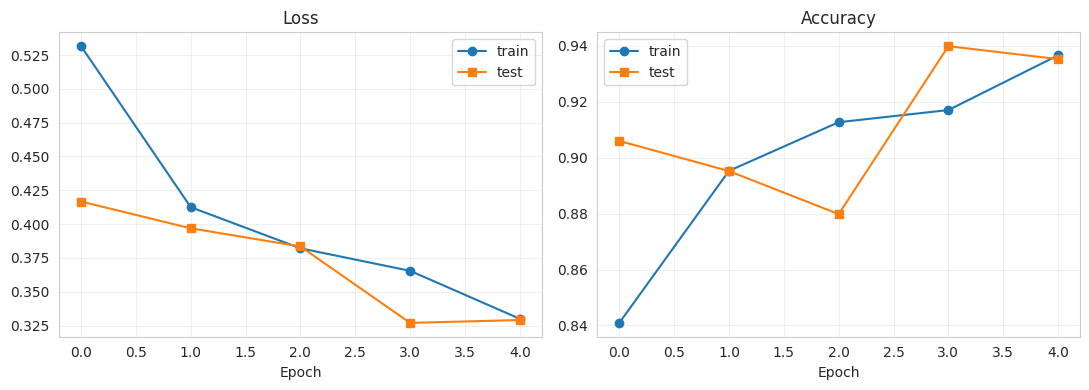

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history['train_loss'], 'o-', label='train')
ax[0].plot(history['test_loss'],  's-', label='test')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(history['train_acc'], 'o-', label='train')
ax[1].plot(history['test_acc'],  's-', label='test')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_y, all_p = [], []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Predicting on test set'):
        x = x.to(DEVICE)
        out = model(x)
        pred = out.argmax(1).cpu().numpy()
        all_y.extend(y.numpy()); all_p.extend(pred)

class_names = list(test_ds.class_to_idx.keys())
print('\nClassification report:\n')
print(classification_report(all_y, all_p, target_names=class_names, digits=4))

Predicting on test set:   0%|          | 0/11 [00:00<?, ?it/s]


Classification report:

              precision    recall  f1-score   support

       Fresh     0.9952    0.9537    0.9740       216
        Ripe     0.8537    0.9722    0.9091       216
      Rotten     0.9745    0.8802    0.9249       217

    accuracy                         0.9353       649
   macro avg     0.9411    0.9354    0.9360       649
weighted avg     0.9412    0.9353    0.9360       649



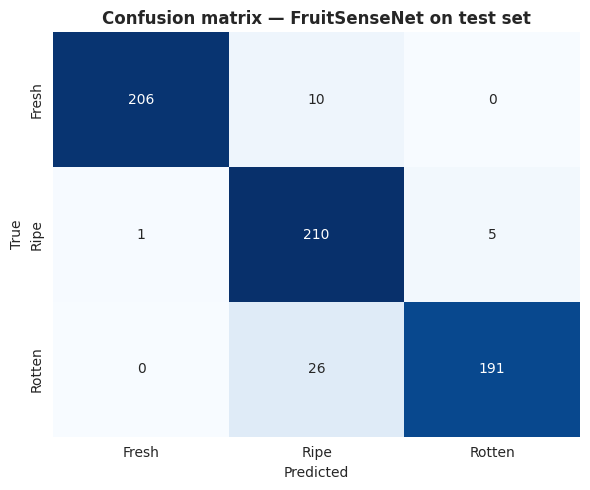

In [ ]:
cm = confusion_matrix(all_y, all_p)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar=False, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion matrix — FruitSenseNet on test set', weight='bold')
plt.tight_layout()
plt.show()

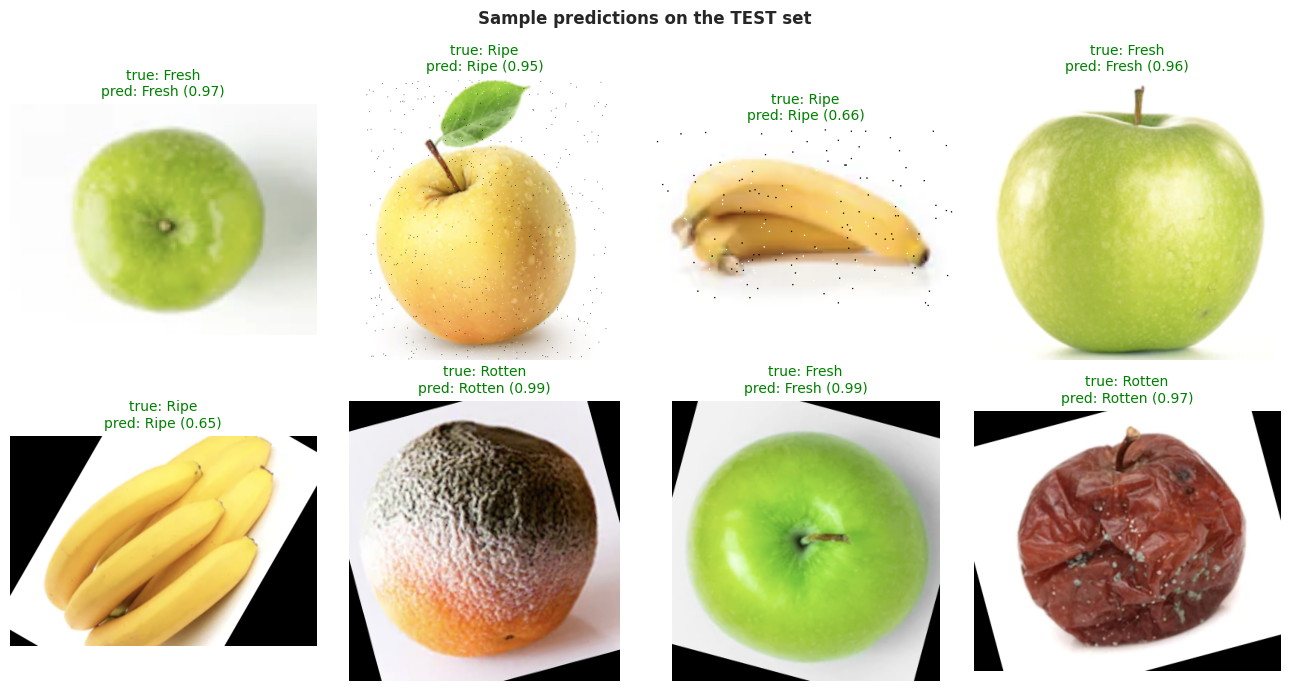

In [ ]:
import numpy as np

idx_to_class = {v: k for k, v in test_ds.class_to_idx.items()}
n_show = 8
indices = np.random.choice(len(test_ds), n_show, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(13, 7))
model.eval()
with torch.no_grad():
    for ax, i in zip(axes.flat, indices):
        x, y = test_ds[i]
        logits = model(x.unsqueeze(0).to(DEVICE))
        probs = F.softmax(logits, dim=1).cpu().numpy()[0]
        pred = int(probs.argmax())
        true_lbl = idx_to_class[y]
        pred_lbl = idx_to_class[pred]
        img = Image.open(test_ds.samples[i][0]).convert('RGB')
        ax.imshow(img); ax.axis('off')
        ok = (pred == y)
        ax.set_title(f'true: {true_lbl}\npred: {pred_lbl} ({probs[pred]:.2f})',
                      color='green' if ok else 'red', fontsize=10)
plt.suptitle('Sample predictions on the TEST set', weight='bold')
plt.tight_layout()
plt.show()

---

## Summary for the reviewer

| Item | Value |
|---|---|
| Source dataset | Kaggle — `sriramr/fruits-fresh-and-rotten-for-classification` |
| Classes | **Fresh**, **Ripe**, **Rotten** |
| Ripe class generation | Synthesised from Fresh by HSV colour-classifying yellow/red/orange ripeness cues |
| Train / Test split | **85% / 15%**, stratified by class, `random_state=42` |
| Image size | 224 × 224, ImageNet normalisation |
| Train augmentations | RandomResizedCrop, HorizontalFlip, ColorJitter |
| Test transform | Resize + CenterCrop only (no augmentation) |
| Model | **FruitSenseNet** — 5 ConvBlocks + DCFNet (FFT correlation filter) + 3-layer MLP head |
| Optimizer | AdamW, lr=1e-3, weight_decay=1e-4, CosineAnnealing schedule |
| Loss | CrossEntropy with label smoothing 0.05 |
| Metrics | Accuracy, per-class precision / recall / F1, confusion matrix |

The trained `model_best.pth` is dropped into `backend/ml/checkpoints/` and the FastAPI service flips from mock mode (`MODEL_MOCK=true`) to real inference (`MODEL_MOCK=false`) — same model used live by the React frontend on <http://localhost:3000>.